# 🌊 Shoreline Extraction API: Step-by-Step Jupyter Notebook Tutorial

Welcome! This notebook will guide you through running predictions on your own images using the SOCIB Shoreline Extraction API. The steps are simple, well-documented, and include visual outputs so anyone can follow along and understand the results.

## 🛠️ What You Need to Follow This Tutorial

- **Docker** (to run the API)
- **Python** (recommended version 3.8 or higher)
- **Conda or Mamba** (for easy environment setup)
- **Jupyter Notebook** (to run this tutorial)
- Basic familiarity with running notebook cells (no advanced coding knowledge required!)

## 🐳 Getting Docker

If you don't have Docker installed, follow the official instructions here:
- [Docker Installation Guide](https://docs.docker.com/get-docker/)

Docker lets you run the Beach Wracks API easily, without worrying about dependencies.

## 🧪 Creating a Conda or Mamba Environment

To keep things organized and avoid conflicts, create a new environment for this tutorial. You can use either Conda or Mamba. Choose the cell below that matches your preferred tool and copy the commands directly!

- **From your terminal:**

    🟢 conda environment setup
    ```bash
    conda create -n socib-shoreline-extraction python=3.10 jupyterlab notebook opencv requests ipython -y
    ```

    🔵 mamba environment setup (faster)
    ```bash
    mamba create -n socib-shoreline-extraction python=3.10 jupyterlab notebook opencv requests ipython -y
    ```

## 📦 Importing Required Packages

In [1]:
# Import all necessary packages
import cv2  # For image handling
import requests  # For API communication
import os  # For file and folder operations
from IPython.display import Image, display  # To show images in the notebook
import json  # For handling JSON data

print("✅ Packages imported successfully!")

✅ Packages imported successfully!


## 🚀 Running the Docker Container

To use the API, you need to start the Docker container. You can do this:

- **From your terminal:**
    ```bash
    docker run -ti -p 5000:5000 ai4oshub/socib-shoreline-extraction
    ```

- **From inside the notebook (advanced):**
Run the cell below to start the container using Python.

In [2]:
# Run the Docker container from the notebook (optional)
import subprocess

docker_command = [
    "docker", "run", "-d", "-p", "5000:5000", "ai4oshub/socib-beach-wracks-identification"
]

result = subprocess.run(docker_command, capture_output=True, text=True)
if len(result.stderr) > 0:
    print("Error starting Docker container:", result.stderr.strip())
else:
    print("Docker container started successfully! Container ID:", result.stdout.strip())

Error starting Docker container: docker: Error response from daemon: failed to set up container networking: driver failed programming external connectivity on endpoint fervent_aryabhata (2968c9a38effe31d539c53a99b7a67221c09aaf0c91d91724626caf5b9f37fd4): Bind for :::5000 failed: port is already allocated

Run 'docker run --help' for more information


## 🌐 Setting the API URL and Endpoint

The API URL tells the notebook where to send your images for prediction. If you run the Docker container as shown above, the default is:

- Base URL: `http://localhost:5000`. 5000 is the port of your local host where the container is published. Change this in the cell below if you used a different port in the "docker run".

- Endpoint: `/v2/models/socib_shoreline_extraction/predict/`. Do not modify the endpoint.

In [3]:
# Set the API URL and endpoint
base_url = "http://localhost:5000"
endpoint = "/v2/models/socib_shoreline_extraction/predict/"
API_URL = base_url + endpoint
print(f"API URL set to: {API_URL}")

API URL set to: http://localhost:5000/v2/models/socib_shoreline_extraction/predict/


## 🎛️ 3. Choosing Your Prediction Settings

You can customize how the API processes the shoreline extraction. Unlike object detection, here we focus on image geometry and specific areas of interest:

* **Rectified**: Set to `True` if the input image is an orthophoto (top-down view). Set to `False` if it is a perspective or oblique photo from a standard camera.
* **Boolean Crop ROI**: Set to `True` if you want to focus the detection on a specific part of the image to improve accuracy or speed.
* **Crop ROI**: A list of four coordinates `[x_min, y_min, x_max, y_max]` defining the box you want to analyze (only used if *Boolean Crop ROI* is True).
* **Output type**: Choose between:
    * `image/png`: To receive a visual image with the detected shoreline drawn on top.
    * `application/json`: To receive a list of $(x, y)$ coordinates for data analysis. **Note:** Coordinates are in pixels, where $(0,0)$ represents the **top-left corner** of the image.

Set your preferences below!

In [17]:
# --- SET YOUR PREFERENCES HERE ---

output_type = "image/png"        # Options: "image/png" (visual), "application/json" (coordinates)
rectified_option = True          # Options: True (rectified), False (oblique/perspective)
use_roi = False                  # Set to True to crop a specific region before processing
roi_coordinates = [640, 480, 1000, 2000]  # Region of Interest [x_min, y_min, x_max, y_max]

print("Prediction settings configured!")

Prediction settings configured!


## 🤖 Making a Prediction: The Request Function

Let's define a function that sends your image to the API and gets the prediction. We'll explain each step with comments and print statements so you know what's happening.

In [ ]:
def predict_image(image_path):
    """
    Sends an image to the Shoreline API and returns the prediction result.
    - image_path: Path to your coastal image file
    """
    if not os.path.exists(image_path):
        print(f"❌ Error: File not found at {image_path}. Please check the path.")
        return None

    print(f"Loading image: {image_path}")
    img = cv2.imread(image_path)
    if img is None:
        print("❌ Could not load image. Check the file format.")
        return None

    # Encode image to JPEG
    success, encoded_img = cv2.imencode(".jpg", img)
    if not success:
        print("❌ Failed to encode image.")
        return None
    image_bytes = encoded_img.tobytes()

    # Prepare the request
    files = {"file": ("input.jpg", image_bytes, "image/jpeg")}

    # API parameters using your defined preference variables
    options = {
        "rectified": rectified_option,
        "boolean_crop_roi": use_roi,
        "crop_roi": roi_coordinates,
        "accept": "image/*" if output_type.startswith("image/") else "application/json"
    }

    # Set the headers based on your output_type preference
    headers = {"accept": output_type}

    print("📤 Sending request to API...")
    response = requests.post(API_URL, headers=headers, data=options, files=files)

    if response.status_code == 200:
        print("✅ Prediction successful!")
        
        if output_type == "application/json":
            return response.json()
        else:
            return Image(data=response.content)
    else:
        print(f"❌ Prediction failed (status: {response.status_code})")
        print("Response:", response.text)
        return None

## 🖼️ Example: Predicting a Single Image

Let's try predicting on a single image. We'll show the result and explain what it means.

Loading image: ../data/rectified.jpg
📤 Sending request to API...
✅ Prediction successful!
<IPython.core.display.Image object>
Showing predicted image:


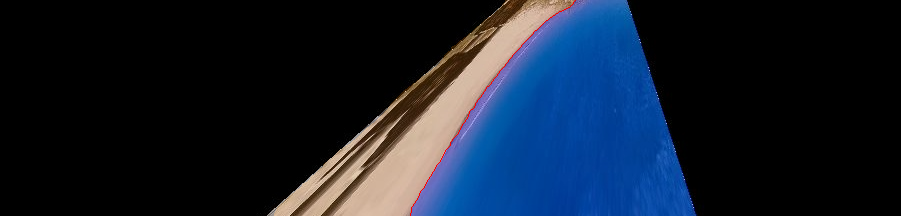

In [21]:
# Path to your test image
image_path = "../data/rectified.jpg"  # Update with your image path
# Predict results
result = predict_image(image_path)

print(result)

# Display results
if isinstance(result, Image):
    print("Showing predicted image:")
    display(result)
elif isinstance(result, dict):
    print("Prediction result (JSON):")
    print(json.dumps(result, indent=2))
else:
    print("No result to show.")

 # Add here your code to save results if needed (e.g., save images or JSON outputs to disk)

## 📂 Example: Predicting All Images in a Folder

You can also run predictions on all images in a folder. This is useful for batch processing.

In [ ]:
# Folder containing your images
folder_path = "path/to/your/images"  # Update with your folder path
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

print(f"Found {len(image_files)} images in the folder.")

for img_file in image_files:
    # Generate image path
    img_path = os.path.join(folder_path, img_file)
    
    # Predict results
    result = predict_image(img_path)

    # Display results
    if isinstance(result, Image):
        display(result)
    elif isinstance(result, dict):
        print(json.dumps(result, indent=2))
    else:
        print("No result.")
    
    # Add here your code to save results if needed (e.g., save images or JSON outputs to disk)

---

# 🎉 Congratulations!

You have now run predictions on your own images using the Shoreline Extraction API. If you have questions or want to explore more, check the API documentation or reach out for support.

**Tips:**
- Try different prediction settings to see how results change.
- Use your own images for testing.
- Share your feedback to help improve the tutorial!

🌟 **Important:** When you finish, remember to stop the Docker container to free up your computer's resources!

To stop the container, open your terminal and run:

```bash
docker ps  # Find the container ID or name (e.g., shoreline-extraction-api)
docker stop <container_id_or_name>
```

If you want to remove it completely:

```bash
docker rm <container_id_or_name>
```

Happy predicting! 🌊